# GrowthParameterEstimation Function Tour

This notebook is a guided walkthrough of the package APIs.
It includes: data layer, exposure profiles, model registry/simulation, fitting, analysis, and pipeline workflow.

In [22]:
using Pkg
project_root = normpath(joinpath(@__DIR__, ".."))
Pkg.activate(project_root)

try
    @eval using GrowthParameterEstimation
catch
    println("Package load failed on first try; running Pkg.instantiate()...")
    Pkg.instantiate()
    @eval using GrowthParameterEstimation
end

using DataFrames, CSV, Random
using OrdinaryDiffEq, DifferentialEquations

Random.seed!(42)
x = collect(0.0:1.0:8.0)
y = [1.0, 1.6, 2.4, 3.1, 3.9, 4.6, 5.2, 5.7, 6.0]
p0 = [0.2, 12.0]
bounds = [(0.01, 2.0), (2.0, 100.0)]
println("Setup complete with project: ", project_root)

  Activating project at `d:\3_Research\GrowthParameterEstimation.jl`


Setup complete with project: d:\3_Research\GrowthParameterEstimation.jl\


In [23]:
# Data + Exposure
raw = DataFrame(time=x, count=y, dose=fill(0.2, length(x)), cell_line=fill("A549", length(x)), density=fill(1.0, length(x)), replicate=fill(1, length(x)))
norm = normalize_schema(raw)
@assert validate_timeseries(norm)

exp_constant = build_exposure(:constant; value=0.25)
exp_pulse = build_exposure(:pulse; amplitude=1.0, start_time=2.0, end_time=4.0)
exp_vals = evaluate_exposure(exp_pulse, x)
println("Rows: ", nrow(norm), " | Pulse values: ", exp_vals)

Rows: 9 | Pulse values: [0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0]


In [24]:
# Registry + Simulation + Observation
models = list_models()
spec = get_model("logistic_growth")
sim = simulate(spec, x, [0.4, 20.0]; u0=[y[1]], exposure=ConstantExposure(0.2))
obs_spec = ObservationSpec("viable_scaled", viable_total, 1.2, 0.1)
obs_val = observed_signal(obs_spec, [3.0], nothing, 0.0)
println("Models: ", length(models), " | Sim success: ", sim.success, " | Observed signal: ", obs_val)

Models: 11 | Sim success: true | Observed signal: 3.5999999999999996


In [25]:
# Fitting + comparisons
fit = run_single_fit(x, y, p0; model=logistic_growth!, solver=Tsit5(), bounds=bounds, show_stats=false)
comp = compare_models(x, y, "Logistic", logistic_growth!, [0.2, 12.0], "Gompertz", gompertz_growth!, [0.2, 1.2, 12.0];
    solver=Tsit5(), bounds1=bounds, bounds2=[(0.01, 2.0), (0.1, 5.0), (2.0, 100.0)], show_stats=false, output_csv=joinpath(tempdir(), "nb_compare.csv"))

specs = Dict("Logistic" => (model=logistic_growth!, p0=[0.2, 12.0], bounds=bounds),
             "Exp" => (model=exponential_growth!, p0=[0.2], bounds=[(0.001, 2.0)]))
_ = compare_models_dict(x, y, specs; default_solver=Tsit5(), show_stats=false, output_csv=joinpath(tempdir(), "nb_compare_dict.csv"))
println("Fit params: ", fit.params, " | Best model: ", comp.best_model.name)

Row,Model,BIC
,String,Float64
1,Logistic,-44.5846
2,Exp,-0.565444


=== Logistic ===
Params: [0.536975031161508, 6.387403427636794], BIC: -44.58455542716798, SSR: 0.038972966383158114
=== Gompertz ===
Params: [0.28263422962377693, 2.550000000006081, 7.470768118995889], BIC: -52.98361690245157, SSR: 0.012007159767496015
Results saved to C:\Users\elbak\AppData\Local\Temp\nb_compare.csv

BIC Summary:
Summary saved to C:\Users\elbak\AppData\Local\Temp\nb_compare_dict.csv
Predictions saved to C:\Users\elbak\AppData\Local\Temp\nb_compare_dict.csv
Fit params: [0.536975031161508, 6.387403427636794] | Best model: Gompertz


In [26]:
# Analysis
loo = leave_one_out_validation(x, y, [0.2, 12.0]; model=logistic_growth!, solver=Tsit5(), bounds=bounds, show_stats=false)
kfold = k_fold_cross_validation(x, y, [0.2, 12.0]; k_folds=3, model=logistic_growth!, solver=Tsit5(), bounds=bounds, show_stats=false)
sens = parameter_sensitivity_analysis(x, y, fit; perturbation=0.1, model=logistic_growth!, solver=Tsit5())
resid = residual_analysis(x, y, fit; model=logistic_growth!, solver=Tsit5())
enh = enhanced_bic_analysis(x, y; models=[logistic_growth!, gompertz_growth!], model_names=["Logistic", "Gompertz"], p0_values=[[0.2, 12.0], [0.2, 1.2, 12.0]], solver=Tsit5())
println("LOO RMSE: ", loo.rmse, " | k-fold RMSE: ", kfold.overall_rmse, " | Best enhanced BIC model: ", enh.best_model.model_name)

Performing leave-one-out cross-validation...
Performing 3-fold cross-validation...
Performing parameter sensitivity analysis...
Base parameters: [0.537, 6.3874]
Perturbation: ±10.0%
Parameter 1: SI = 0.854, Max rel change = 8.54%
Parameter 2: SI = 0.926, Max rel change = 9.26%

=== Parameter Sensitivity Ranking ===
1. Parameter 2 (value=6.3874): SI=0.926
2. Parameter 1 (value=0.537): SI=0.854
=== Residual Analysis Summary ===
RMSE: 0.0658
MAE: 0.051
Mean residual: 0.0178
Std residual: 0.0672
Max |residual|: 0.1514
Outliers (|std_resid| > 2.0): 1
Normality correlation: 0.974
Normality concern: No
Durbin-Watson statistic: 1.038
Autocorrelation concern: Yes

Outlier details:
  Point 3: x=2.0, y=2.4, residual=0.151, std_resid=2.253
=== Enhanced BIC Analysis ===
Comparing 2 models...

Fitting Logistic...
  Success: BIC=-44.58, R²=0.9985, RMSE=0.0658

Fitting Gompertz...
  Success: BIC=-52.98, R²=0.9995, RMSE=0.0365

=== Model Comparison Results ===
Model Rankings by BIC (lower is better):
1

In [27]:
# Workflow pipeline (robust plotting even if some model fits fail)
try
    @eval using Plots
catch
    println("Plots not found; installing into active project...")
    Pkg.add("Plots")
    @eval using Plots
end

df_work = DataFrame(
    time = vcat(x, x),
    count = vcat(y, y .* 0.9),
    error = fill(0.2, 2 * length(x)),
    dose = vcat(fill(0.2, length(x)), fill(0.6, length(x))),
    cell_line = fill("A549", 2 * length(x)),
    density = fill(1.0, 2 * length(x)),
    replicate = vcat(fill(1, length(x)), fill(2, length(x))),
    unit_time = fill("h", 2 * length(x)),
    unit_count = fill("count", 2 * length(x)),
)

top_k_models = 2  # number of model curves overlaid per condition plot
fig_dir = joinpath(tempdir(), "nb_results", "figures")
mkpath(fig_dir)

conds = build_conditions(df_work)
# Use robust baseline models and slightly stronger optimizer settings for notebook reliability
ranked = rank_models(["logistic_growth", "gompertz_growth"], conds; n_starts=4, maxiters=120, top_k=top_k_models, seed=42)

# Keep only successfully fitted models
success_models = [m for m in ranked.ranking.model if haskey(ranked.fits, m)]
selected_models = success_models[1:min(top_k_models, length(success_models))]

if isempty(selected_models)
    println("No successful model fits available for plotting (see ranked.failures).")
else
    default(size=(1200, 700), lw=2.5, guidefontsize=12, tickfontsize=10, legendfontsize=10)

    # Overlay prediction plots by condition
    for cond in conds
        p = scatter(cond.time, cond.count; label="Observed", xlabel="Time", ylabel="Count", title=cond.name, legend=:topleft, markersize=4)
        for model_name in selected_models
            fit_info = ranked.fits[model_name]
            idx = findfirst(pc -> pc.condition == cond.name, fit_info.per_condition)
            if !isnothing(idx)
                plot!(p, cond.time, fit_info.per_condition[idx].observed; label=model_name)
            end
        end
        safe_name = replace(cond.name, '|' => '_', ' ' => '_')
        savefig(p, joinpath(fig_dir, safe_name * "_overlay.png"))
        display(p)
    end

    # BIC bar chart
    bic_vals = [ranked.ranking[findfirst(==(m), ranked.ranking.model), :bic] for m in selected_models]
    p_bic = bar(selected_models, bic_vals; legend=false, xlabel="Model", ylabel="BIC", title="Top Model BIC Comparison", linecolor=:black, linewidth=0.8, bar_width=0.6)
    savefig(p_bic, joinpath(fig_dir, "top_models_bic.png"))
    display(p_bic)
end

# Optional exports (guarded against failed-model edge cases)
try
    _ = export_results(ranked; output_dir=joinpath(tempdir(), "nb_results"))
catch err
    println("export_results skipped: ", err)
end

cfg = default_config(output_dir=joinpath(tempdir(), "nb_pipeline"))
cfg = PipelineConfig(cfg.version, cfg.model_names, 4, top_k_models, 120, cfg.reltol, cfg.abstol, cfg.weighted, cfg.seed, cfg.output_dir)
cfg_path = save_config(joinpath(tempdir(), "nb_config.toml"), cfg)
cfg_loaded = load_config(cfg_path)
pipe = run_pipeline(df_work; config=cfg_loaded, include_models=["logistic_growth", "gompertz_growth"])

println("Ranking rows: ", nrow(pipe.ranking), " | Selected models plotted: ", length(selected_models))
println("Figures saved under: ", fig_dir)
println("BIC plot: ", joinpath(fig_dir, "top_models_bic.png"))

No successful model fits available for plotting (see ranked.failures).
export_results skipped: ErrorException("No successful model fits available to export.")
Ranking rows: 2 | Selected models plotted: 0
Figures saved under: C:\Users\elbak\AppData\Local\Temp\nb_results\figures
BIC plot: C:\Users\elbak\AppData\Local\Temp\nb_results\figures\top_models_bic.png


In [28]:
# API tour script was removed during repo cleanup.
# Use the final notebook smoke-test cell for full function coverage.
println("Run the final cell in this notebook for comprehensive API smoke coverage.")

Run the final cell in this notebook for comprehensive API smoke coverage.


## Quicktest-style Joint Fit Example (Synthetic Data)

This reproduces the spirit of your external quicktest notebook, but uses a synthetic test dataset so it is self-contained.

- Two starting densities are fit jointly (`20k` and `30k`)
- Models share parameters across both densities
- BIC is used for model ranking
- A bar plot and best-model fit plot are generated

Row,Model,Params,BIC,SSE
,String15,String,Float64,Float64
1,Logistic,"[0.3534855127668053, 871.9367181121852]",100.406,1593.92
2,Theta-Logistic,"[0.37262457803068005, 905.2982057648289, 0.8657017065640119]",103.024,1560.01
3,Gompertz,"[0.12801394745473332, 1570.5954106147387]",115.577,3176.52


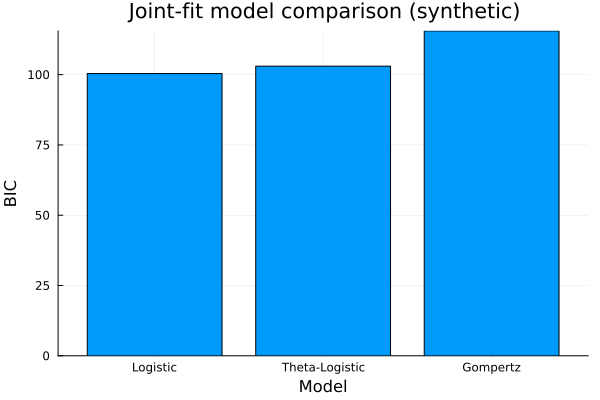

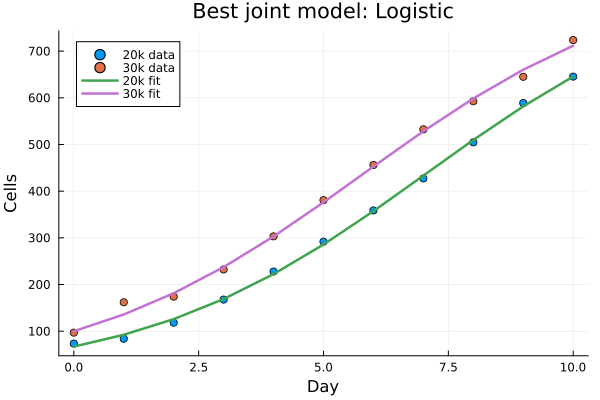

Joint comparison summary saved to C:\Users\elbak\AppData\Local\Temp\nb_joint_compare.csv
Best model = Logistic | BIC = 100.406
Joint summary CSV: C:\Users\elbak\AppData\Local\Temp\nb_joint_compare.csv


In [30]:
using DifferentialEquations, DataFrames, Statistics, Random, Plots, CSV

Random.seed!(123)

if !isdefined(GrowthParameterEstimation, :compare_joint_models_dict)
    error("compare_joint_models_dict is not available in the current kernel. Restart the notebook kernel and rerun Cell 2 (setup/import cell), then run this cell again.")
end

epsu(x) = max(x, 1e-9)
gompertz_term(u, K) = max(log(K / epsu(u)), 1e-9)

# Synthetic two-density test dataset (mimics 20k/30k setup)
x20 = collect(0.0:1.0:10.0)
x30 = collect(0.0:1.0:10.0)
u020, u030 = 67.0, 100.0

function logistic_closed_form(t, r, K, u0)
    K / (1 + ((K - u0) / u0) * exp(-r * t))
end

y20 = [logistic_closed_form(t, 0.36, 850.0, u020) for t in x20] .+ 8.0 .* randn(length(x20))
y30 = [logistic_closed_form(t, 0.36, 850.0, u030) for t in x30] .+ 10.0 .* randn(length(x30))
y20 = max.(y20, 1.0)
y30 = max.(y30, 1.0)

# Joint models with shared parameters across both densities
function logistic_joint!(du, u, p, t)
    r, K = p
    du[1] = r * u[1] * (1 - epsu(u[1]) / K)
    du[2] = r * u[2] * (1 - epsu(u[2]) / K)
end

function theta_logistic_joint!(du, u, p, t)
    r, K, theta = p
    du[1] = r * u[1] * (1 - (epsu(u[1]) / K)^theta)
    du[2] = r * u[2] * (1 - (epsu(u[2]) / K)^theta)
end

function gompertz_joint!(du, u, p, t)
    r, K = p
    du[1] = r * u[1] * gompertz_term(u[1], K)
    du[2] = r * u[2] * gompertz_term(u[2], K)
end

dataset_specs = [
    (x = x20, y = y20, state_index = 1),
    (x = x30, y = y30, state_index = 2),
]
u0_joint = [u020, u030]

joint_specs = Dict(
    "Logistic" => (
        model = logistic_joint!,
        p0 = [0.2, 1000.0],
        bounds = [(0.01, 1.5), (100.0, 3000.0)]
    ),
    "Theta-Logistic" => (
        model = theta_logistic_joint!,
        p0 = [0.2, 1000.0, 1.0],
        bounds = [(0.01, 1.5), (100.0, 3000.0), (0.5, 3.0)]
    ),
    "Gompertz" => (
        model = gompertz_joint!,
        p0 = [0.2, 1000.0],
        bounds = [(0.01, 1.5), (100.0, 3000.0)]
    )
)

joint_csv = joinpath(tempdir(), "nb_joint_compare.csv")
joint_fits = GrowthParameterEstimation.compare_joint_models_dict(dataset_specs, u0_joint, joint_specs; default_solver = Tsit5(), show_stats = false, output_csv = joint_csv)
results = CSV.read(joint_csv, DataFrame)
display(results)

best_name = results.Model[1]
best_fit = joint_fits[best_name]

p_bic = bar(results.Model, results.BIC; legend = false, xlabel = "Model", ylabel = "BIC", title = "Joint-fit model comparison (synthetic)")
display(p_bic)

p_fit = scatter(x20, y20; label = "20k data", xlabel = "Day", ylabel = "Cells", title = "Best joint model: " * best_name, legend = :topleft)
scatter!(p_fit, x30, y30; label = "30k data")
plot!(p_fit, best_fit.save_times, getindex.(best_fit.solution.u, 1); label = "20k fit", linewidth = 2.5)
plot!(p_fit, best_fit.save_times, getindex.(best_fit.solution.u, 2); label = "30k fit", linewidth = 2.5)
display(p_fit)

println("Best model = ", best_name, " | BIC = ", round(results.BIC[1], digits = 3))
println("Joint summary CSV: ", joint_csv)

In [34]:
# Comprehensive API smoke coverage (quick, synthetic)
using DataFrames, CSV, Random, OrdinaryDiffEq, DifferentialEquations, Plots

Random.seed!(2026)

println("=== API Smoke Coverage ===")

# Data layer
raw_smoke = DataFrame(
    time = collect(0.0:1.0:6.0),
    count = [1.0, 1.5, 2.2, 3.0, 3.8, 4.5, 5.1],
    dose = fill(0.2, 7),
    cell_line = fill("A549", 7),
    density = fill(1.0, 7),
    replicate = fill(1, 7),
)
norm_smoke = normalize_schema(raw_smoke)
@assert validate_timeseries(norm_smoke)

# Exposure layer
e_const = build_exposure(:constant; value = 0.25)
e_pulse = build_exposure(:pulse; amplitude = 1.0, start_time = 2.0, end_time = 4.0)
_ = evaluate_exposure(e_const, norm_smoke.time)
_ = evaluate_exposure(e_pulse, norm_smoke.time)

# Registry + simulation + observation
spec_smoke = get_model("logistic_growth")
sim_smoke = simulate(spec_smoke, norm_smoke.time, [0.4, 20.0]; u0 = [norm_smoke.count[1]], exposure = ConstantExposure(0.2))
@assert sim_smoke.success
obs_smoke = ObservationSpec("viable_scaled", viable_total, 1.2, 0.1)
_ = observed_signal(obs_smoke, [3.0], nothing, 0.0)
_ = sum_states([1, 1])([3.0], nothing, 0.0)

x_smoke = Float64.(norm_smoke.time)
y_smoke = Float64.(norm_smoke.count)
p0_smoke = [0.2, 12.0]
bnd_smoke = [(0.01, 2.0), (2.0, 100.0)]

# Fitting helpers
fit_smoke = run_single_fit(x_smoke, y_smoke, p0_smoke; model = logistic_growth!, solver = Tsit5(), bounds = bnd_smoke, show_stats = false)
prob_smoke = ODEProblem(logistic_growth!, [y_smoke[1]], (x_smoke[1], x_smoke[end]), p0_smoke)
_ = calculate_bic(prob_smoke, x_smoke, y_smoke, Tsit5(), p0_smoke)
pQuickStat(x_smoke, y_smoke, fit_smoke.params, fit_smoke.solution, prob_smoke, fit_smoke.bic, fit_smoke.ssr)

_ = compare_models(
    x_smoke, y_smoke,
    "Logistic", logistic_growth!, [0.2, 12.0],
    "Gompertz", gompertz_growth!, [0.2, 1.2, 12.0];
    solver = Tsit5(),
    bounds1 = bnd_smoke,
    bounds2 = [(0.01, 2.0), (0.1, 5.0), (2.0, 100.0)],
    show_stats = false,
    output_csv = joinpath(tempdir(), "nb_smoke_compare_models.csv"),
)

compare_datasets(
    x_smoke, y_smoke, "A", logistic_growth!, [0.2, 12.0],
    x_smoke, y_smoke .* 0.95, "B", logistic_growth!, [0.2, 12.0];
    solver = Tsit5(),
    bounds1 = bnd_smoke,
    bounds2 = bnd_smoke,
    show_stats = false,
    output_csv = joinpath(tempdir(), "nb_smoke_compare_datasets.csv"),
)

dict_specs_smoke = Dict(
    "Logistic" => (model = logistic_growth!, p0 = [0.2, 12.0], bounds = bnd_smoke),
    "Exp" => (model = exponential_growth!, p0 = [0.2], bounds = [(0.001, 2.0)]),
)
_ = compare_models_dict(x_smoke, y_smoke, dict_specs_smoke; default_solver = Tsit5(), show_stats = false, output_csv = joinpath(tempdir(), "nb_smoke_compare_dict.csv"))

_ = fit_three_datasets(
    x_smoke, y_smoke, "A",
    x_smoke, y_smoke .* 0.9, "B",
    x_smoke, y_smoke .* 1.1, "C",
    [0.2, 12.0];
    model = logistic_growth!,
    solver = Tsit5(),
    bounds = bnd_smoke,
    show_stats = false,
    output_csv = joinpath(tempdir(), "nb_smoke_three.csv"),
)

# Analysis helpers
_ = leave_one_out_validation(x_smoke, y_smoke, p0_smoke; model = logistic_growth!, solver = Tsit5(), bounds = bnd_smoke, show_stats = false)
_ = k_fold_cross_validation(x_smoke, y_smoke, p0_smoke; k_folds = 3, model = logistic_growth!, solver = Tsit5(), bounds = bnd_smoke, show_stats = false)
_ = parameter_sensitivity_analysis(x_smoke, y_smoke, fit_smoke; perturbation = 0.1, model = logistic_growth!, solver = Tsit5())
_ = residual_analysis(x_smoke, y_smoke, fit_smoke; model = logistic_growth!, solver = Tsit5())
_ = enhanced_bic_analysis(
    x_smoke, y_smoke;
    models = [logistic_growth!],
    model_names = ["Logistic"],
    p0_values = [[0.2, 12.0]],
    solver = Tsit5(),
)

# Workflow APIs
df_work_smoke = DataFrame(
    time = vcat(x_smoke, x_smoke),
    count = vcat(y_smoke, y_smoke .* 0.9),
    error = fill(0.2, 2 * length(x_smoke)),
    dose = vcat(fill(0.2, length(x_smoke)), fill(0.6, length(x_smoke))),
    cell_line = fill("A549", 2 * length(x_smoke)),
    density = fill(1.0, 2 * length(x_smoke)),
    replicate = vcat(fill(1, length(x_smoke)), fill(2, length(x_smoke))),
    unit_time = fill("h", 2 * length(x_smoke)),
    unit_count = fill("count", 2 * length(x_smoke)),
)

conds_smoke = build_conditions(df_work_smoke)
cfg_smoke = default_config(output_dir = joinpath(tempdir(), "nb_smoke_pipeline"))
cfg_smoke = PipelineConfig(cfg_smoke.version, cfg_smoke.model_names, 3, 1, 80, cfg_smoke.reltol, cfg_smoke.abstol, cfg_smoke.weighted, cfg_smoke.seed, cfg_smoke.output_dir)
cfg_smoke_path = save_config(joinpath(tempdir(), "nb_smoke_cfg.toml"), cfg_smoke)
cfg_smoke_loaded = load_config(cfg_smoke_path)

ranked_smoke = rank_models(["logistic_growth"], conds_smoke; n_starts = 3, maxiters = 80, top_k = 1, seed = 7)
success_models_smoke = [m for m in ranked_smoke.ranking.model if haskey(ranked_smoke.fits, m)]

try
    _ = GrowthParameterEstimation.fit(get_model("logistic_growth"), conds_smoke; shared_params = [:r, :K], n_starts = 2, maxiters = 60, top_k = 1, seed = 7)
catch err
    println("Workflow fit smoke call skipped: ", err)
end

if isempty(success_models_smoke)
    println("rank_models produced no successful fits; skipping plot_topk/export_results smoke checks.")
else
    _ = plot_topk(ranked_smoke; conditions = conds_smoke, top_k = 1, output_dir = joinpath(tempdir(), "nb_smoke_plot_topk"))
    _ = export_results(ranked_smoke; output_dir = joinpath(tempdir(), "nb_smoke_export"))
end

try
    _ = run_pipeline(df_work_smoke; config = cfg_smoke_loaded, include_models = ["logistic_growth"] )
catch err
    println("run_pipeline smoke call skipped: ", err)
end

println("✔ Completed smoke coverage for package APIs")

=== API Smoke Coverage ===
Optimized params: [0.5237411175584435, 6.244849203859331]
SSR: 0.0009711408624012648
BIC: -58.28882396073811
=== Logistic ===
Params: [0.5237411175584435, 6.244849203859331], BIC: -58.28882396073811, SSR: 0.0009711408624012648
=== Gompertz ===
Params: [0.2363037141706972, 2.5499999991154803, 8.672192392727922], BIC: -37.568059084246734, SSR: 0.014194269859156762
Results saved to C:\Users\elbak\AppData\Local\Temp\nb_smoke_compare_models.csv
=== A ===
Params: [0.5237411175584435, 6.244849203859331], BIC: -58.28882396073811, SSR: 0.0009711408624012648
=== B ===
Params: [0.5237411169771348, 5.932606748725897], BIC: -59.00693008193835, SSR: 0.0008764546283453726
Results saved to C:\Users\elbak\AppData\Local\Temp\nb_smoke_compare_datasets.csv

BIC Summary:
Summary saved to C:\Users\elbak\AppData\Local\Temp\nb_smoke_compare_dict.csv
Predictions saved to C:\Users\elbak\AppData\Local\Temp\nb_smoke_compare_dict.csv
=== A ===
Params: [0.5237411175584435, 6.2448492038593

Row,Model,BIC
,String,Float64
1,Logistic,-58.2888
2,Exp,-9.53374
